<a href="https://colab.research.google.com/github/mishti127/Deep-learning/blob/main/Momentum_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 0: Loss = 0.4884
Epoch 500: Loss = 0.0635

ACTUAL vs PREDICTED (Momentum GD)
Input [0 0] | Actual: 0 | Predicted: 0 (value = 0.000)
Input [0 1] | Actual: 0 | Predicted: 0 (value = 0.055)
Input [1 0] | Actual: 0 | Predicted: 0 (value = 0.055)
Input [1 1] | Actual: 1 | Predicted: 1 (value = 0.935)



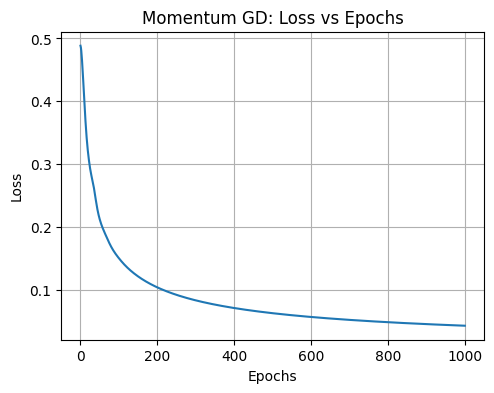

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[0],[0],[1]])

lr = 0.1
epochs = 1000
beta = 0.9

np.random.seed(1)
weights = np.random.randn(2,1)
bias = 0.0

vw = np.zeros_like(weights)
vb = 0.0
loss_history = []

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(y):
    return y * (1 - y)

# Training
for epoch in range(epochs):
    z = np.dot(X, weights) + bias
    output = sigmoid(z)

    error = y - output
    d_output = error * sigmoid_derivative(output)

    grad_w = np.dot(X.T, d_output)
    grad_b = np.sum(d_output)

    vw = beta * vw + lr * grad_w
    vb = beta * vb + lr * grad_b

    weights += vw
    bias += vb

    loss = np.mean(np.abs(error))
    loss_history.append(loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.4f}")

# Final prediction
final_output = sigmoid(np.dot(X, weights) + bias)
predicted = (final_output > 0.5).astype(int)

print("\nACTUAL vs PREDICTED (Momentum GD)")
for i in range(len(X)):
    print(f"Input {X[i]} | Actual: {y[i][0]} | "
          f"Predicted: {predicted[i][0]} "
          f"(value = {final_output[i][0]:.3f})")
print()
# Plots
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Momentum GD: Loss vs Epochs")
plt.grid(True)

plt.show()
